In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Ajuste o caminho conforme onde o notebook estiver
df = pd.read_csv("../data/processed/country_risk_dataset.csv")

df.head()

,country,countryiso3code,date,gdp_per_capita,population,inflation,life_expectancy
0,Africa Eastern and Southern,AFE,2025,1722.385620,788844284.0,4.270111,NaN
1,Africa Eastern and Southern,AFE,2024,1628.227289,769280888.0,4.770857,65.349930
2,Africa Eastern and Southern,AFE,2023,1571.132704,750491370.0,7.399186,65.146228
3,Africa Eastern and Southern,AFE,2022,1675.902524,731821393.0,10.883478,64.487152
4,Africa Eastern and Southern,AFE,2021,1560.894626,713090928.0,6.824727,62.979999


In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 17490
Columns: 7


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17490 entries, 0 to 17489
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country          17490 non-null  str    
 1   countryiso3code  17160 non-null  str    
 2   date             17490 non-null  int64  
 3   gdp_per_capita   14745 non-null  float64
 4   population       17394 non-null  float64
 5   inflation        11472 non-null  float64
 6   life_expectancy  17126 non-null  float64
dtypes: float64(4), int64(1), str(2)
memory usage: 956.6 KB


In [4]:
df.describe()

,date,gdp_per_capita,population,inflation,life_expectancy
count,17490.000000,14745.000000,1.739400e+04,11472.000000,17126.000000
mean,1992.500000,8919.926659,2.197147e+08,19.307981,64.906125
std,19.050916,17945.875543,7.243716e+08,282.592631,11.085830
min,1960.000000,11.801322,2.715000e+03,-17.640424,10.989000
25%,1976.000000,595.918898,1.010953e+06,2.372799,57.946000
50%,1992.500000,1993.586672,6.758138e+06,4.775528,67.331500
75%,2009.000000,8243.898955,4.616106e+07,9.524845,73.044775
max,2025.000000,288001.574856,8.215425e+09,23773.131774,86.497000


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

country                str
countryiso3code        str
date                 int64
gdp_per_capita     float64
population         float64
inflation          float64
life_expectancy    float64
dtype: object

In [7]:
df["country"].nunique()

265

In [8]:
sorted(df["date"].unique())

[np.int64(1960),
 np.int64(1961),
 np.int64(1962),
 np.int64(1963),
 np.int64(1964),
 np.int64(1965),
 np.int64(1966),
 np.int64(1967),
 np.int64(1968),
 np.int64(1969),
 np.int64(1970),
 np.int64(1971),
 np.int64(1972),
 np.int64(1973),
 np.int64(1974),
 np.int64(1975),
 np.int64(1976),
 np.int64(1977),
 np.int64(1978),
 np.int64(1979),
 np.int64(1980),
 np.int64(1981),
 np.int64(1982),
 np.int64(1983),
 np.int64(1984),
 np.int64(1985),
 np.int64(1986),
 np.int64(1987),
 np.int64(1988),
 np.int64(1989),
 np.int64(1990),
 np.int64(1991),
 np.int64(1992),
 np.int64(1993),
 np.int64(1994),
 np.int64(1995),
 np.int64(1996),
 np.int64(1997),
 np.int64(1998),
 np.int64(1999),
 np.int64(2000),
 np.int64(2001),
 np.int64(2002),
 np.int64(2003),
 np.int64(2004),
 np.int64(2005),
 np.int64(2006),
 np.int64(2007),
 np.int64(2008),
 np.int64(2009),
 np.int64(2010),
 np.int64(2011),
 np.int64(2012),
 np.int64(2013),
 np.int64(2014),
 np.int64(2015),
 np.int64(2016),
 np.int64(2017),
 np.int64(2018

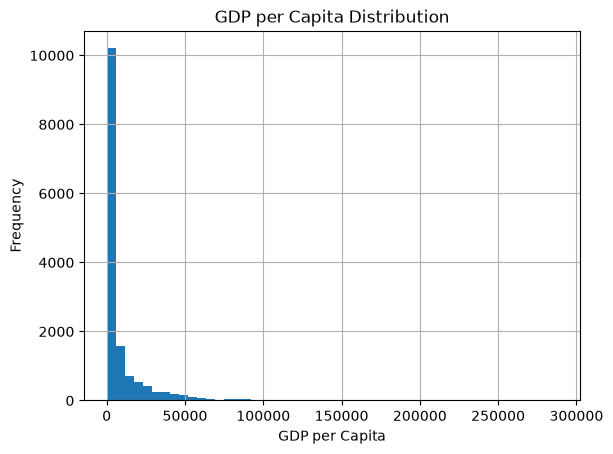

In [9]:
df["gdp_per_capita"].hist(bins=50)

plt.title("GDP per Capita Distribution")
plt.xlabel("GDP per Capita")
plt.ylabel("Frequency")

plt.show()

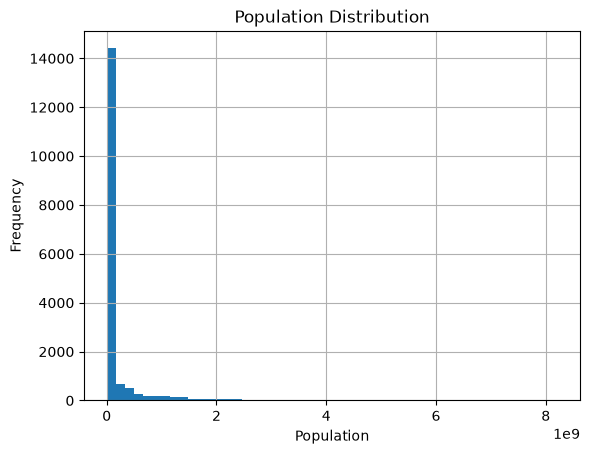

In [10]:
df["population"].hist(bins=50)

plt.title("Population Distribution")
plt.xlabel("Population")
plt.ylabel("Frequency")

plt.show()

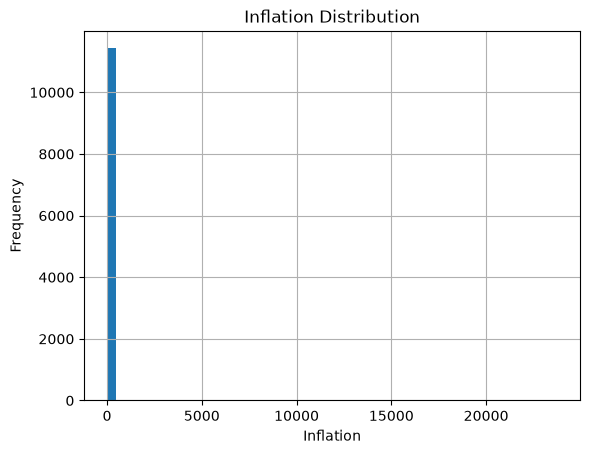

In [11]:
df["inflation"].hist(bins=50)

plt.title("Inflation Distribution")
plt.xlabel("Inflation")
plt.ylabel("Frequency")

plt.show()

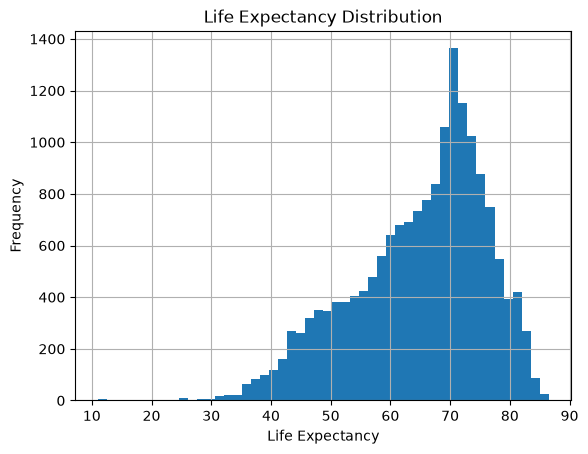

In [12]:
df["life_expectancy"].hist(bins=50)

plt.title("Life Expectancy Distribution")
plt.xlabel("Life Expectancy")
plt.ylabel("Frequency")

plt.show()

In [13]:
numeric_df = df.select_dtypes(include="number")

numeric_df.corr()

,date,gdp_per_capita,population,inflation,life_expectancy
date,1.000000,0.345247,0.091309,-0.020660,0.497086
gdp_per_capita,0.345247,1.000000,-0.071943,-0.027209,0.531398
population,0.091309,-0.071943,1.000000,-0.013538,0.016513
inflation,-0.020660,-0.027209,-0.013538,1.000000,-0.039469
life_expectancy,0.497086,0.531398,0.016513,-0.039469,1.000000


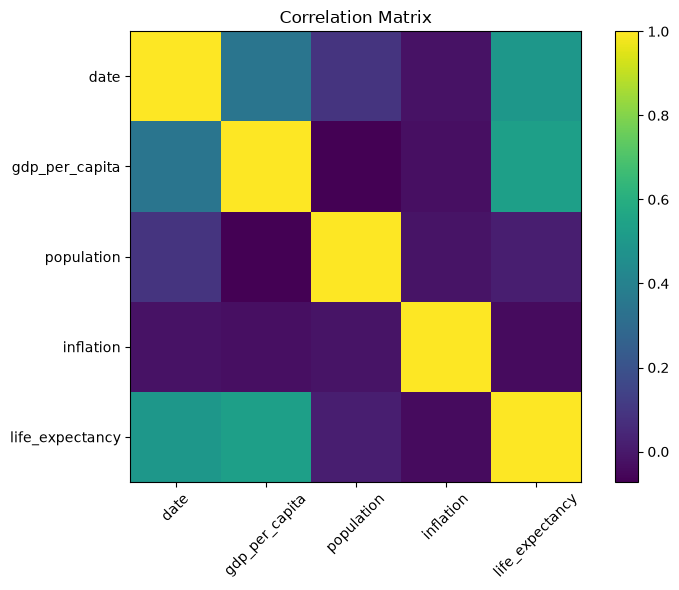

In [14]:
correlation = numeric_df.corr()

plt.figure(figsize=(8,6))

plt.imshow(correlation)

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)

plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.colorbar()

plt.title("Correlation Matrix")

plt.tight_layout()

plt.show()

In [15]:
top_gdp = (
    df[df["date"] == 2024]
    .sort_values("gdp_per_capita", ascending=False)
    .head(10)
)

top_gdp[["country", "gdp_per_capita"]]

,country,gdp_per_capita
11749,Monaco,288001.574856
10693,Liechtenstein,220167.225474
4555,Bermuda,142250.433195
10825,Luxembourg,137781.681659
9307,Ireland,112894.953241
15577,Switzerland,107702.065940
5545,Cayman Islands,104292.900672
14455,Singapore,94896.562150
12871,Norway,89888.953520
16765,United States,86169.664158


In [16]:
lowest_gdp = (
    df[df["date"] == 2024]
    .sort_values("gdp_per_capita")
    .head(10)
)

lowest_gdp[["country", "gdp_per_capita"]]

,country,gdp_per_capita
5215,Burundi,216.231929
3169,Afghanistan,416.871146
5611,Central African Republic,516.161000
11023,Malawi,522.365366
10957,Madagascar,550.378755
14785,"Somalia, Fed. Rep.",629.538899
12013,Mozambique,656.976149
6073,"Congo, Dem. Rep.",692.887665
12607,Niger,729.856664
14389,Sierra Leone,806.654650


In [17]:
top_inflation = (
    df[df["date"] == 2024]
    .sort_values("inflation", ascending=False)
    .head(10)
)

top_inflation[["country", "inflation"]]

,country,inflation
3631,Argentina,219.883929
14917,South Sudan,91.440822
16237,Turkiye,58.506451
17227,West Bank and Gaza,53.669146
10429,Lebanon,45.243042
12673,Nigeria,33.241659
9175,"Iran, Islamic Rep.",32.455871
11023,Malawi,32.179650
14389,Sierra Leone,28.633750
6997,"Egypt, Arab Rep.",28.270590


In [18]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing

inflation          6018
gdp_per_capita     2745
life_expectancy     364
countryiso3code     330
population           96
date                  0
country               0
dtype: int64

In [19]:
df.to_csv("../data/processed/eda_dataset.csv", index=False)

print("EDA finished successfully!")

EDA finished successfully!
